## Q1. Import the attached CSV files (Diamond.csv) and answer the following questions:

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import statistics as stat
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('diamonds.csv')
df

,carat,cut,color,clarity,depth,table,weight,size,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,335
...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,5.75,5.76,2757
53936,0.72,Good,D,SI1,63.1,55.0,5.69,5.75,2757
53937,0.70,Very Good,D,SI1,62.8,60.0,5.66,5.68,2757
53938,0.86,Premium,H,SI2,61.0,58.0,6.15,6.12,2757


In [5]:
# A.	Create 2 dataframes out of this dataframe – 1 with all numerical variables and other with all categorical variables.
# Numerical dataframe
df_num = df.select_dtypes(include=['number'])
df_num


,carat,depth,table,weight,size,price
0,0.23,61.5,55.0,3.95,3.98,326
1,0.21,59.8,61.0,3.89,3.84,326
2,0.23,56.9,65.0,4.05,4.07,327
3,0.29,62.4,58.0,4.20,4.23,334
4,0.31,63.3,58.0,4.34,4.35,335
...,...,...,...,...,...,...
53935,0.72,60.8,57.0,5.75,5.76,2757
53936,0.72,63.1,55.0,5.69,5.75,2757
53937,0.70,62.8,60.0,5.66,5.68,2757
53938,0.86,61.0,58.0,6.15,6.12,2757


In [6]:
# Categorical dataframe
df_cat = df.select_dtypes(exclude=['number'])
df_cat

,cut,color,clarity
0,Ideal,E,SI2
1,Premium,E,SI1
2,Good,E,VS1
3,Premium,I,VS2
4,Good,J,SI2
...,...,...,...
53935,Ideal,D,SI1
53936,Good,D,SI1
53937,Very Good,D,SI1
53938,Premium,H,SI2


In [7]:
# B.	Calculate the measure of central tendency of numerical variables using Pandas and statistics libraries and
# check if the calculated values are different between these 2 libraries.
# Mean
pandas_mean = df_num.mean()

# Median
pandas_median = df_num.median()

# Mode
pandas_mode = df_num.mode().iloc[0]   # first mode (in case of multiple)
print("Mean of nueric variables in pandas:\n",pandas_mean)
print("Median of numeric variables in pandas:\n",pandas_median)
print("Mode of numeric variables in pandas:\n",pandas_mode)

Mean of nueric variables in pandas:
 carat        0.797940
depth       61.749405
table       57.457184
weight       5.731157
size         5.734526
price     3932.799722
dtype: float64
Median of numeric variables in pandas:
 carat        0.70
depth       61.80
table       57.00
weight       5.70
size         5.71
price     2401.00
dtype: float64
Mode of numeric variables in pandas:
 carat       0.30
depth      62.00
table      56.00
weight      4.37
size        4.34
price     605.00
Name: 0, dtype: float64


In [8]:
# measures of central tendency in statistics libraries
stats_mean = df_num.apply(lambda x: stat.mean(x.dropna()))
stats_median = df_num.apply(lambda x: stat.median(x.dropna()))
stats_mode = df_num.apply(lambda x: stat.mode(x.dropna()))
print("Mean of nueric variables in stats:\n",stats_mean)
print("Median of numeric variables in stats:\n",stats_median)
print("Mode of numeric variables in stats:\n",stats_mode)

Mean of nueric variables in stats:
 carat        0.797940
depth       61.749405
table       57.457184
weight       5.731157
size         5.734526
price     3932.799722
dtype: float64
Median of numeric variables in stats:
 carat        0.70
depth       61.80
table       57.00
weight       5.70
size         5.71
price     2401.00
dtype: float64
Mode of numeric variables in stats:
 carat       0.30
depth      62.00
table      56.00
weight      4.37
size        4.34
price     605.00
dtype: float64


##### Meaures of central tendency are almost same using pandas and stattistics libraries.

In [9]:
# C. Check the skewness of all numeric variables. 
# Mention against each variable if its highly skewed/light skewed/ Moderately skwewed.
skewness = df_num.skew()
print(skewness)

carat     1.116646
depth    -0.082294
table     0.796896
weight    0.378676
size      2.434167
price     1.618395
dtype: float64


In [10]:
# function to classify skewness 
def classify_skew(x):
    if x < -1 or x > 1:
        return "Highly skewed"
    elif -1 <= x < -0.5 or 0.5 < x <= 1:
        return "Moderately skewed"
    else:
        return "Lightly skewed"

skewness_category = skewness.apply(classify_skew)

# Combine results
skewness_df = pd.DataFrame({
    'Skewness': skewness,
    'Category': skewness_category
})

print(skewness_df)

        Skewness           Category
carat   1.116646      Highly skewed
depth  -0.082294     Lightly skewed
table   0.796896  Moderately skewed
weight  0.378676     Lightly skewed
size    2.434167      Highly skewed
price   1.618395      Highly skewed


In [11]:
# D.	Use the different transformation techniques to convert skewed data found in previous question into normal distribution.
skewed_cols = skewness[abs(skewness) > 0.5].index
print('The skewed columns are:',skewed_cols)

The skewed columns are: Index(['carat', 'table', 'size', 'price'], dtype='object')


In [16]:
#Using log transformation
df_log = df_num.copy()
for col in skewed_cols:
    if (df_num[col] >= 0).all():  # allow zeros
        df_log[col] = np.log1p(df_num[col])  # cleaner & numerically stable


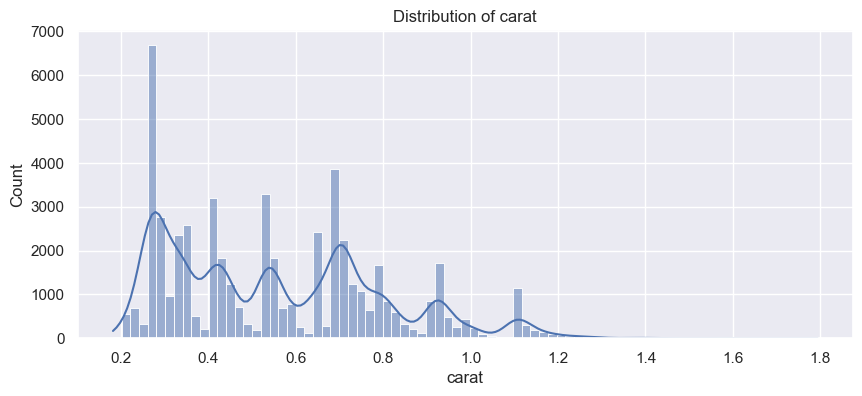

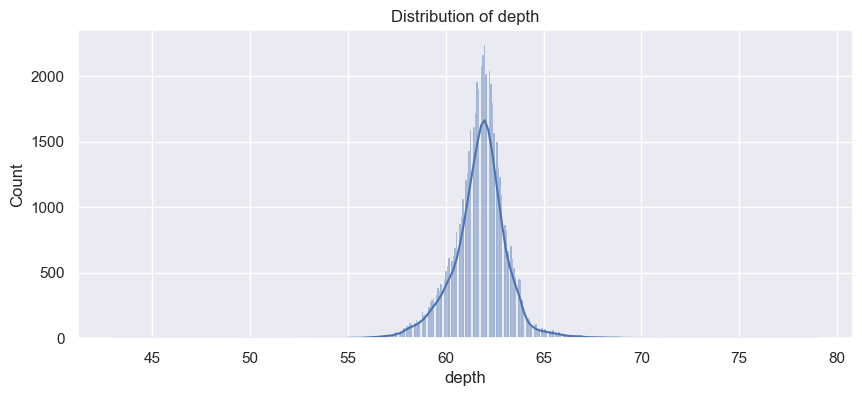

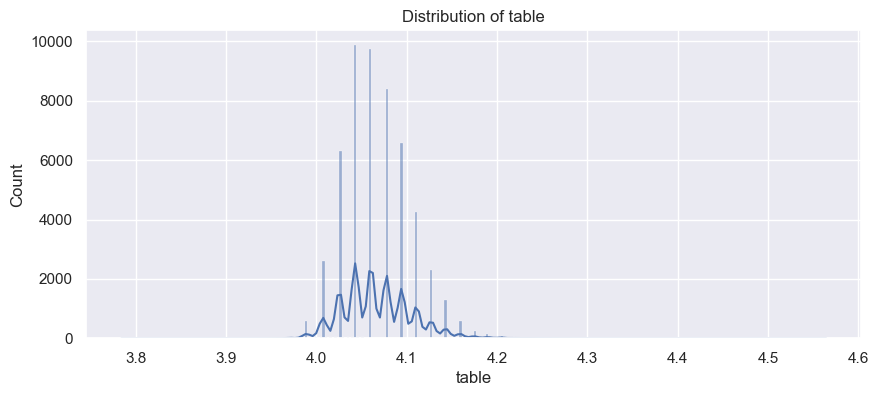

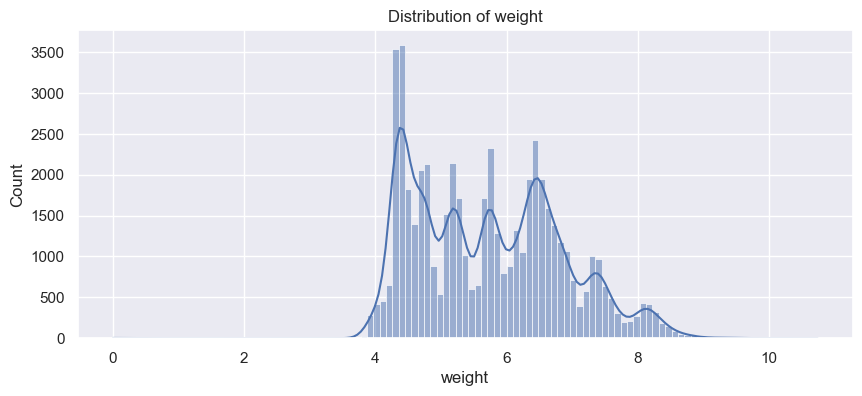

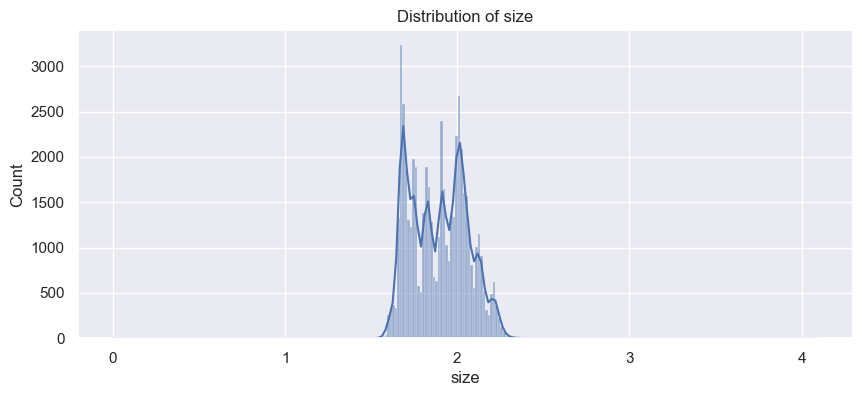

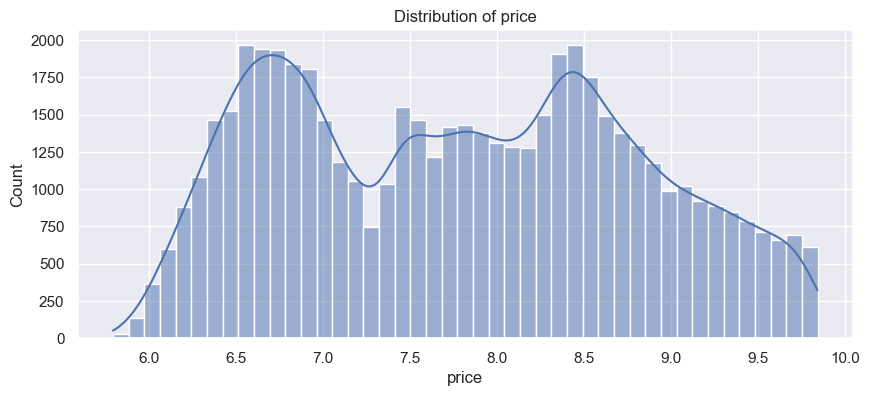

In [17]:
sns.set(rc={'figure.figsize':(10,4)})

for col in df_log.columns:
    plt.figure()  # create new figure for each column
    sns.histplot(df_log[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [19]:
#using square root transformation
df_sqrt = df_num.copy()
for col in skewed_cols:
    if (df_num[col] >= 0).all():
        df_sqrt[col] = np.sqrt(df_num[col])

In [20]:
print("Original Skewness:\n", df_num[skewed_cols].skew())
print("After Transformation:\n", df_sqrt[skewed_cols].skew())

Original Skewness:
 carat    1.116646
table    0.796896
size     2.434167
price    1.618395
dtype: float64
After Transformation:
 carat    0.548471
table    0.692227
size     0.363648
price    0.844396
dtype: float64


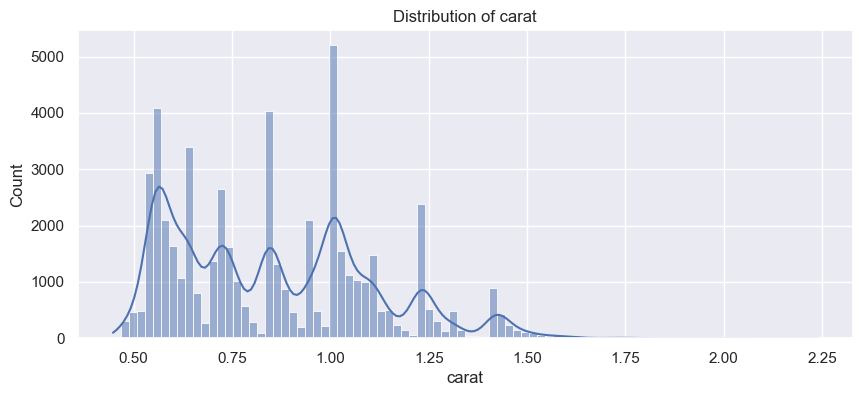

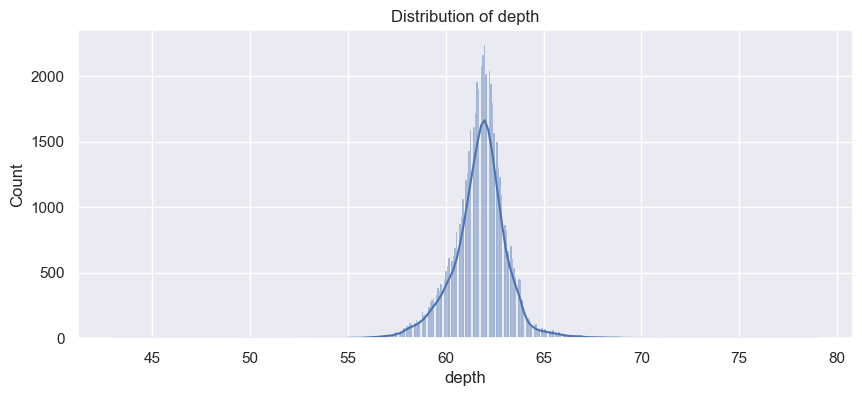

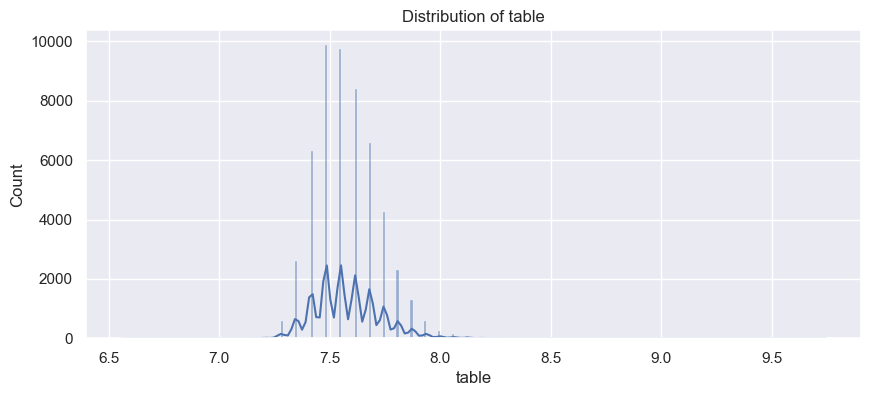

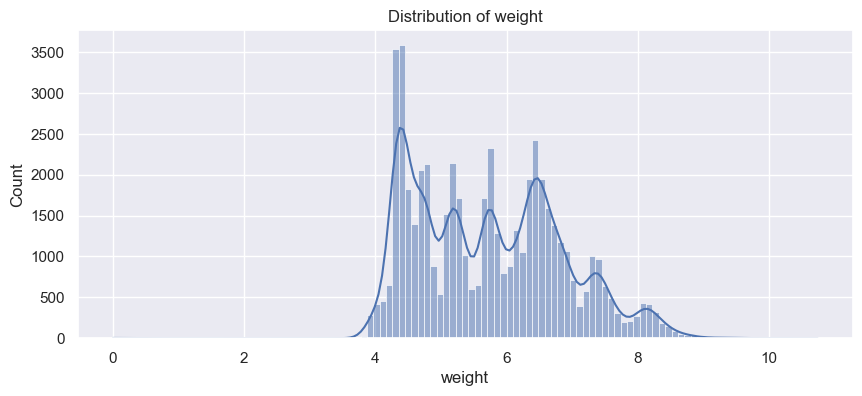

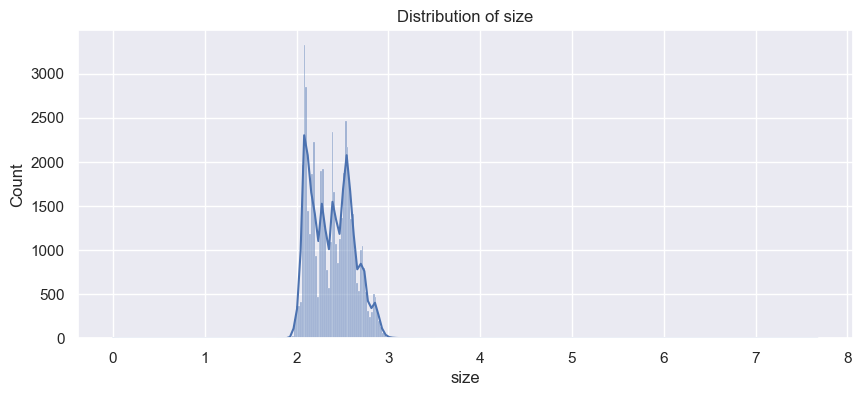

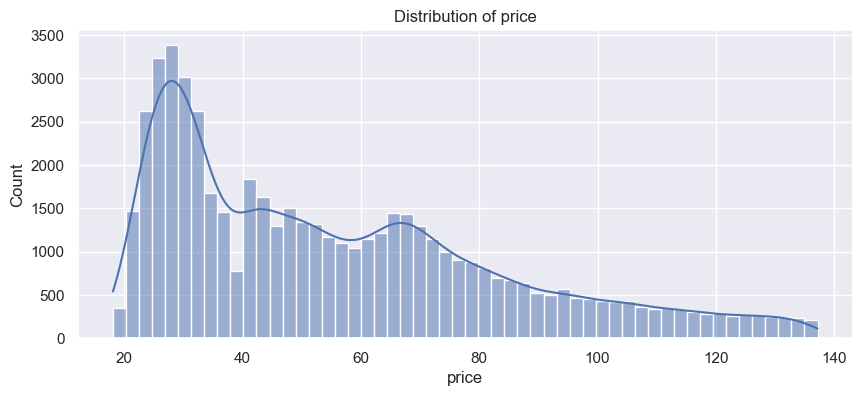

In [21]:
sns.set(rc={'figure.figsize':(10,4)})

for col in df_sqrt.columns:
    plt.figure()  # create new figure for each column
    sns.histplot(df_sqrt[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [22]:
#using cube root transformation
df_cbrt = df_num.copy()
for col in skewed_cols:
    if (df_num[col] >= 0).all():
        df_cbrt[col] = np.cbrt(df_num[col])
print("Original Skewness:\n", df_num[skewed_cols].skew())
print("After Transformation:\n", df_cbrt[skewed_cols].skew())

Original Skewness:
 carat    1.116646
table    0.796896
size     2.434167
price    1.618395
dtype: float64
After Transformation:
 carat    0.386589
table    0.660170
size    -0.132075
price    0.591189
dtype: float64


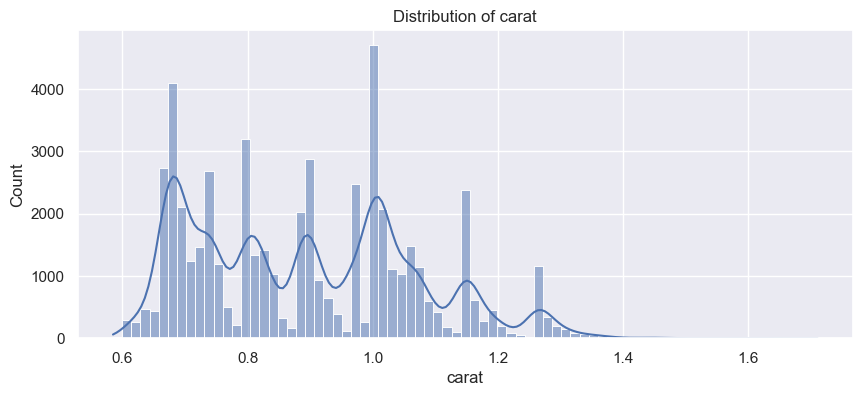

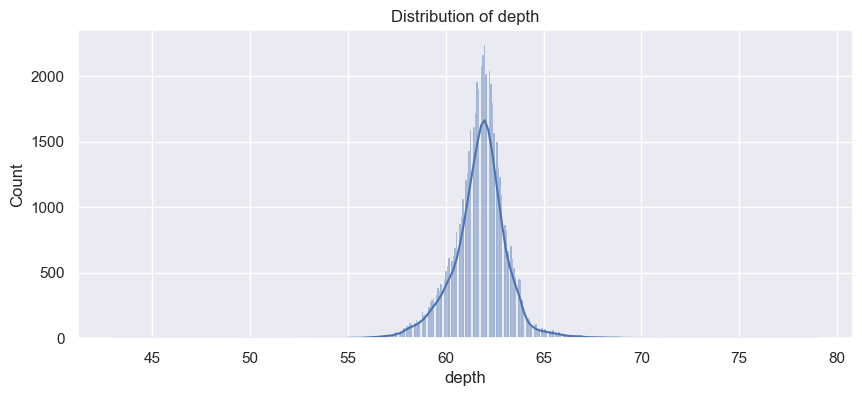

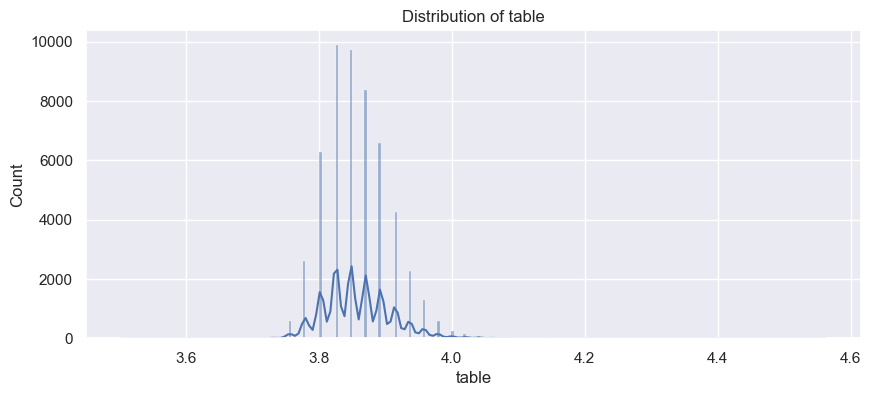

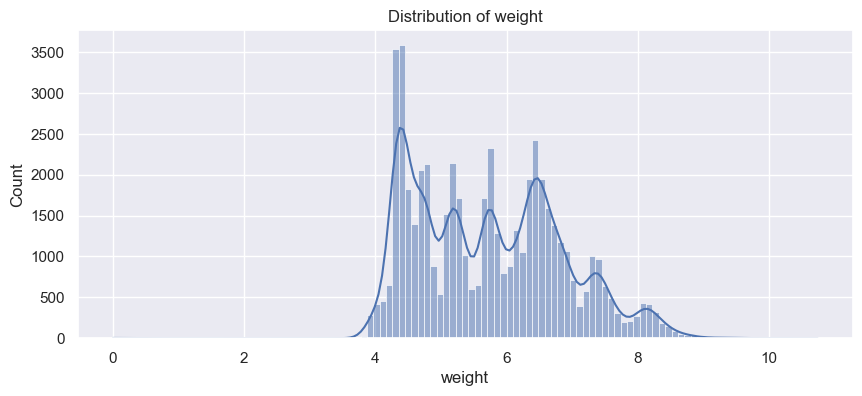

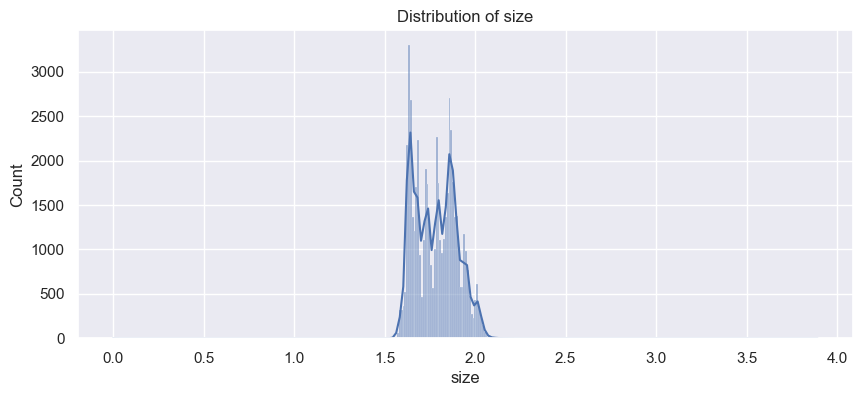

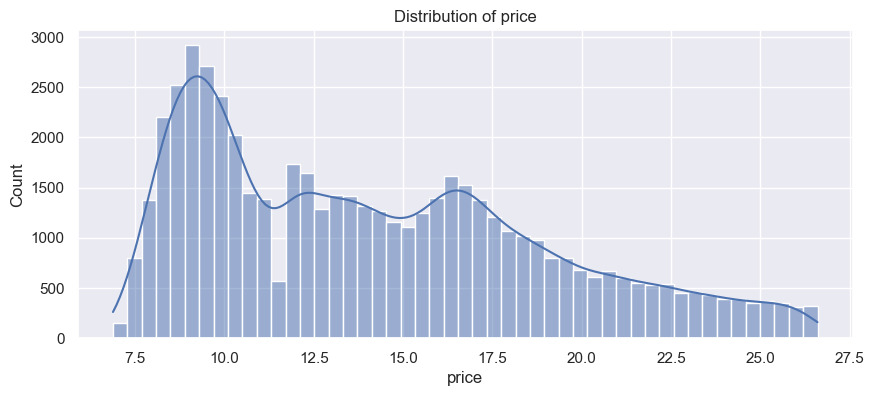

In [23]:
sns.set(rc={'figure.figsize':(10,4)})

for col in df_cbrt.columns:
    plt.figure()  # create new figure for each column
    sns.histplot(df_cbrt[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [1]:
#E.	Create a user defined function in python to check the outliers using IQR method. 
# Then pass all numeric variables in that function to check outliers.


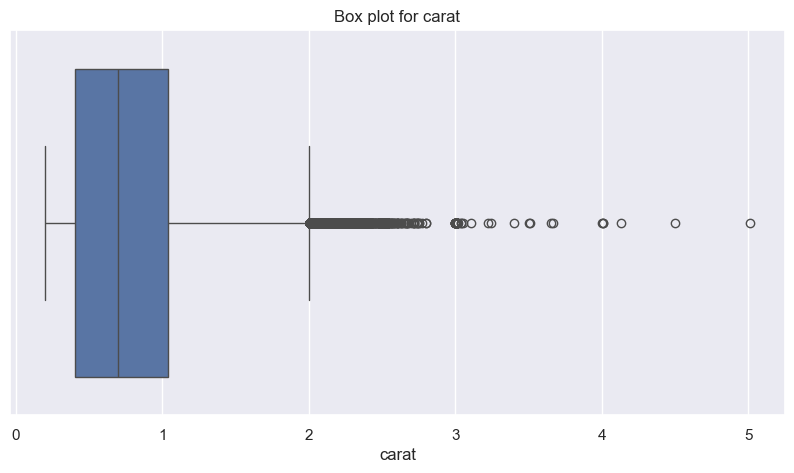

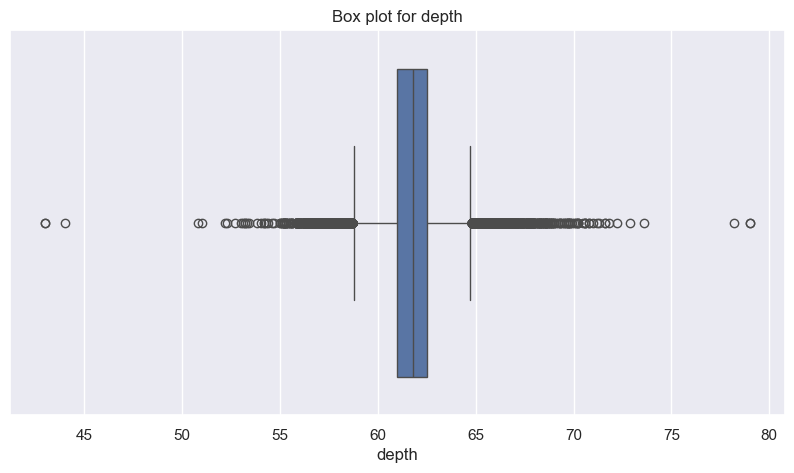

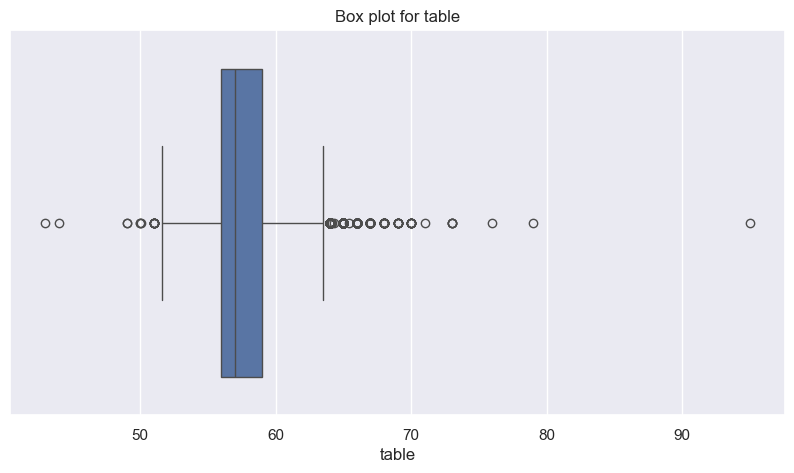

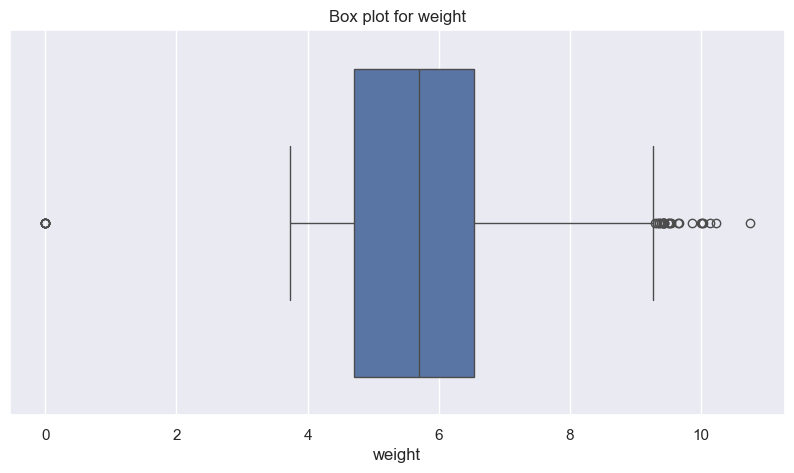

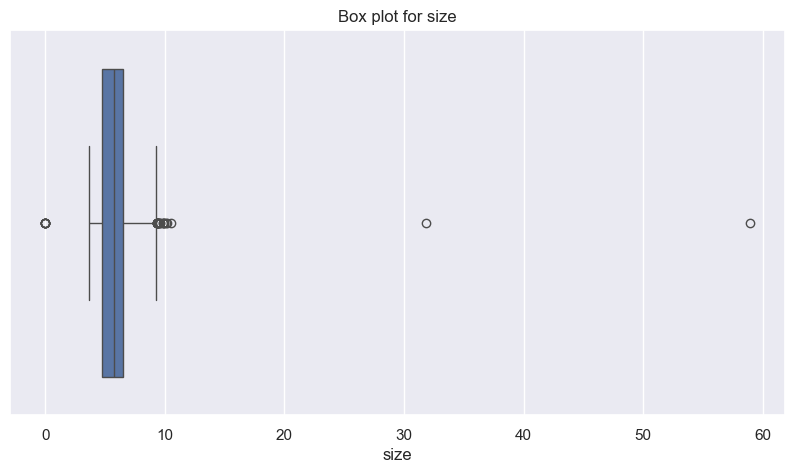

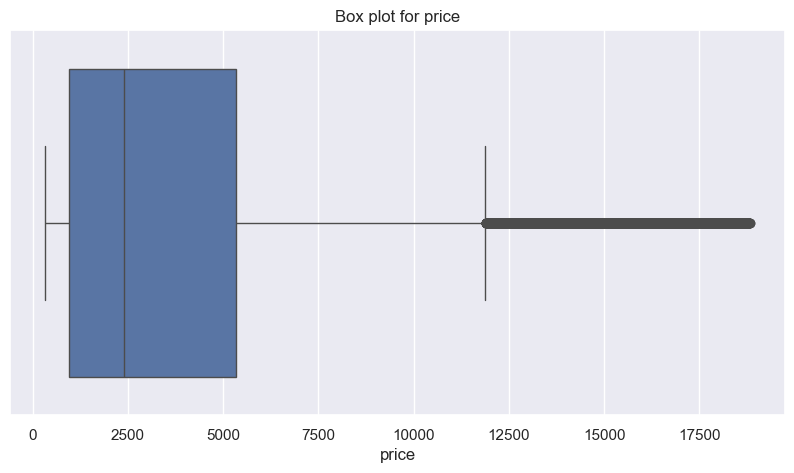

In [76]:
import matplotlib.pyplot as plt

# Plot box plots to visualize outliers
for column in df_num.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[column])
    plt.title(f'Box plot for {column}')
    plt.show()

In [27]:
# user defined function to identify outliers using IQR method
def iqr_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = col[(col < lower_bound) | (col > upper_bound)]
    
    return outliers
outlier_report = df_num.apply(iqr_outliers)
print(outlier_report)


       carat  depth  table  weight  size  price
2        NaN   56.9   65.0     NaN   NaN    NaN
8        NaN   65.1    NaN     NaN   NaN    NaN
24       NaN   58.1    NaN     NaN   NaN    NaN
35       NaN   58.2    NaN     NaN   NaN    NaN
42       NaN   65.2    NaN     NaN   NaN    NaN
...      ...    ...    ...     ...   ...    ...
53882    NaN   65.4    NaN     NaN   NaN    NaN
53886    NaN   58.0    NaN     NaN   NaN    NaN
53890    NaN   57.9    NaN     NaN   NaN    NaN
53895    NaN   57.8    NaN     NaN   NaN    NaN
53927    NaN   58.1    NaN     NaN   NaN    NaN

[6408 rows x 6 columns]


In [29]:
# F.	Convert categorical variables into numerical variables using LabelEncoder technique.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df_encoded = df.copy()

for col in df_cat.columns:
    df_encoded[col] = le.fit_transform(df_cat[col])
print(df_encoded.head())

   carat  cut  color  clarity  depth  table  weight  size  price  median_fare
0   0.23    2      1        3   61.5   55.0    3.95  3.98    326          0.7
1   0.21    3      1        2   59.8   61.0    3.89  3.84    326          0.7
2   0.23    1      1        4   56.9   65.0    4.05  4.07    327          0.7
3   0.29    3      5        5   62.4   58.0    4.20  4.23    334          0.7
4   0.31    1      6        3   63.3   58.0    4.34  4.35    335          0.7


In [30]:
# G.	Use both the feature scaling techniques (standardscaler/min max scaler) on all the variables.
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Assuming df_encoded has all numeric values (after label encoding)
data = df_encoded.copy()
# applying standard scaler
scaler_std = StandardScaler()
df_standard_scaled = pd.DataFrame(
    scaler_std.fit_transform(data),
    columns=data.columns
)

print(df_standard_scaled.head())

      carat       cut     color   clarity     depth     table    weight  \
0 -1.198168 -0.538099 -0.937163 -0.484264 -0.174092 -1.099672 -1.587837   
1 -1.240361  0.434949 -0.937163 -1.064117 -1.360738  1.585529 -1.641325   
2 -1.198168 -1.511147 -0.937163  0.095589 -3.385019  3.375663 -1.498691   
3 -1.071587  0.434949  1.414272  0.675442  0.454133  0.242928 -1.364971   
4 -1.029394 -1.511147  2.002131 -0.484264  1.082358  0.242928 -1.240167   

       size     price   median_fare  
0 -1.536196 -0.904095  1.110223e-16  
1 -1.658774 -0.904095  1.110223e-16  
2 -1.457395 -0.903844  1.110223e-16  
3 -1.317305 -0.902090  1.110223e-16  
4 -1.212238 -0.901839  1.110223e-16  


In [31]:
# applying Min-Max scaling
scaler_minmax = MinMaxScaler()
df_minmax_scaled = pd.DataFrame(
    scaler_minmax.fit_transform(data),
    columns=data.columns
)

print(df_minmax_scaled.head())

      carat   cut     color   clarity     depth     table    weight      size  \
0  0.006237  0.50  0.166667  0.428571  0.513889  0.230769  0.367784  0.067572   
1  0.002079  0.75  0.166667  0.285714  0.466667  0.346154  0.362197  0.065195   
2  0.006237  0.25  0.166667  0.571429  0.386111  0.423077  0.377095  0.069100   
3  0.018711  0.75  0.833333  0.714286  0.538889  0.288462  0.391061  0.071817   
4  0.022869  0.25  1.000000  0.428571  0.563889  0.288462  0.404097  0.073854   

      price  median_fare  
0  0.000000          0.0  
1  0.000000          0.0  
2  0.000054          0.0  
3  0.000433          0.0  
4  0.000487          0.0  


In [ ]:
# H.	Create the Histogram for all numeric variables and draw the KDE plot on that.


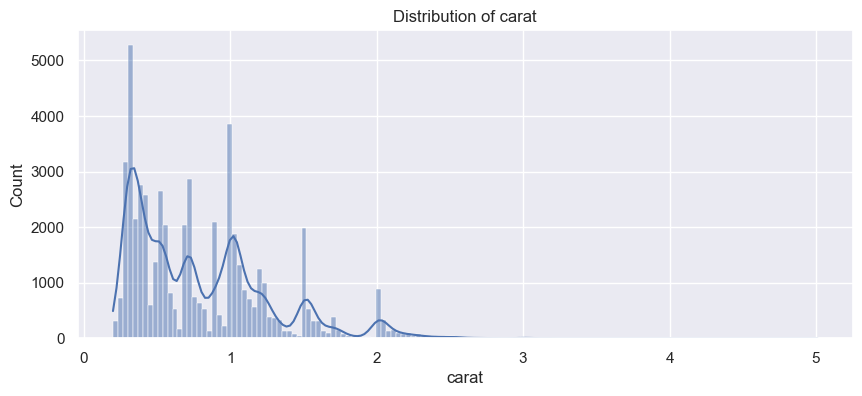

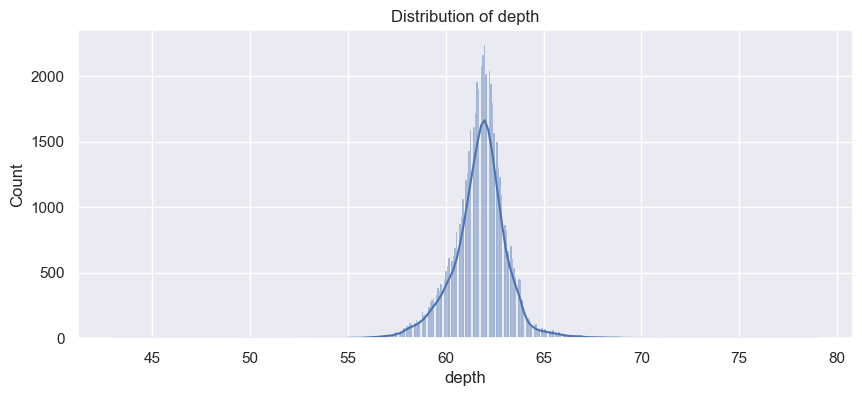

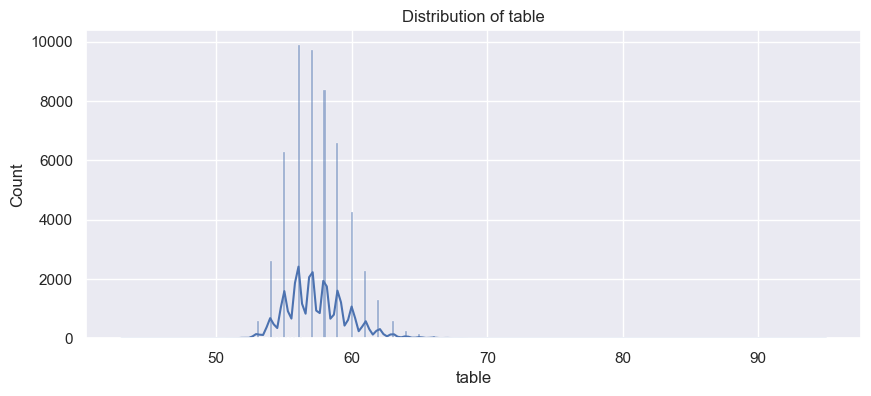

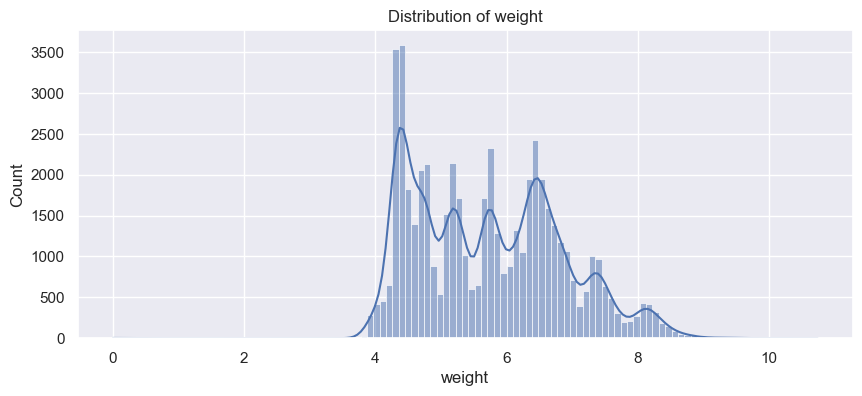

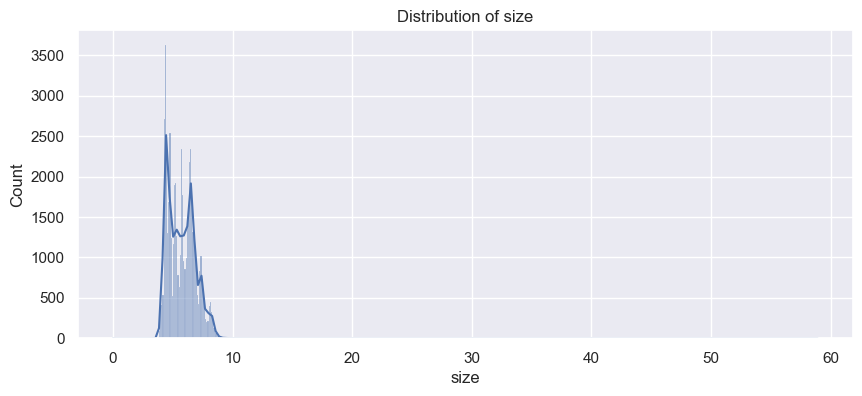

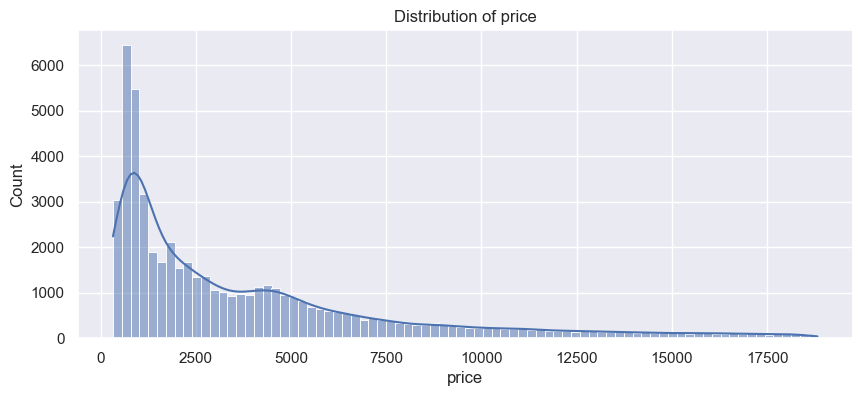

In [59]:
sns.set(rc={'figure.figsize':(10,4)})

for col in df_num.columns:
    plt.figure()  # create new figure for each column
    sns.histplot(df_num[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

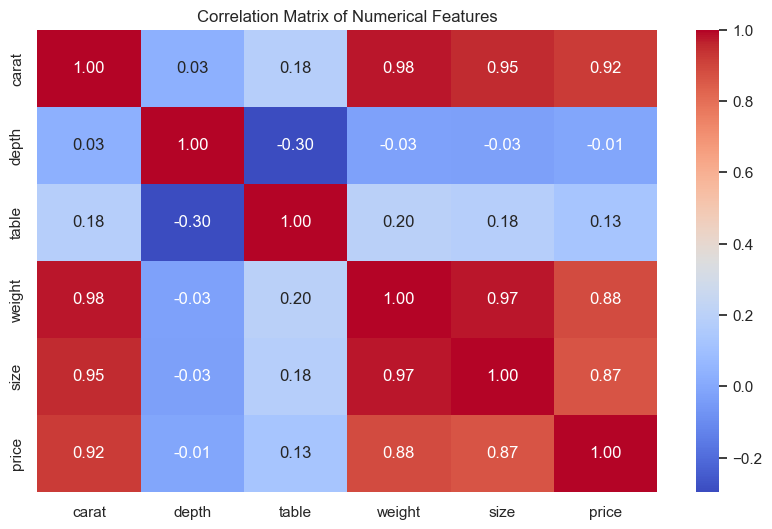

In [60]:
# I.	Check the correlation between all the numeric variables using HeatMap and try to draw some conclusion about the data.
plt.figure(figsize=(10, 6))
sns.heatmap(df_num.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Conclusion about the data
#### The price of diamonds is positively corelated to size, weight and carat of the diamond. Thus, the more the size, weight and carat of the diamond,
#### the more the price of diamond.
#### Carat of diamond i positively corelated with size and weight. Increase in carat would increase the size and weight of the diamond.
#### Similarly, size of the diamond is positively corelated to weight.Increase in size of diamond would increase weight of the diamond.

In [ ]:
# Q2. Explain Gradient descent in detail. How changing the values of learning rate can impact the convergence in Gradient Descent.
Gradient Descent is an algorithm used in machine learning to minimize error (loss function)
by adjusting model parameters step-by-step.
Gradient Descent is a method to find the minimum error by repeatedly moving in the direction of the steepest decrease.
Formula:
θ=θ−α⋅dJ(θ)/dθ
Where:

θ (theta) → model parameters (weights)
α (alpha) → learning rate (step size)
J(θ) → cost function (error)
dJ/dθ → gradient (slope)

Learning Rate (α): This controls how big steps are.

If Learning Rate is too small the effect will be very slow learning.
If learning rate is otimal the effect would be fast convergence. 
If Learning rate is too large, the effect would be overshooting or divergence.